In [22]:
# Imports
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import joblib
import random
import numpy as np
from statistics import mean, stdev
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RepeatedStratifiedKFold
import config

In [23]:
# --------------------------
# Set seeds for reproducibility
# --------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
g = torch.Generator()
g.manual_seed(SEED)


# --------------------------
# Hyperparameters: (for my own reference)
# --------------------------
# lr (learning rate)
# batch size 32
# hidden_dim
# number_of_epochs 
# patience

# =======================
# Custom Dataset
# =======================
class MultimodalDataset(Dataset):
    def __init__(self, clin_path, mrna_path, mut_path, labels_path):
        # Load preprocessed data
        self.clinical = joblib.load(clin_path).to_numpy().astype(float)
        self.mrna = joblib.load(mrna_path).to_numpy().astype(float)
        self.mutation = joblib.load(mut_path).to_numpy().astype(float)
        self.labels = joblib.load(labels_path).to_numpy().astype(float)
        print(self.clinical.shape)
        print(self.mrna.shape)
        print(self.mutation.shape)
                
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.clinical[idx], dtype=torch.float32),
            torch.tensor(self.mrna[idx], dtype=torch.float32),
            torch.tensor(self.mutation[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# =======================
# Paths
# =======================
base_dir = "../preprocessed_data/stability_selection"

train_dataset = MultimodalDataset(
    f"{base_dir}/train/clinical.pkl",
    f"{base_dir}/train/mrna.pkl",
    f"{base_dir}/train/mutation.pkl",
    f"{base_dir}/train/labels.pkl"
)
# FIXME TESTING CHANGED VAL AND TEST
val_dataset = MultimodalDataset(
    f"{base_dir}/val/clinical.pkl",
    f"{base_dir}/val/mrna.pkl",
    f"{base_dir}/val/mutation.pkl",
    f"{base_dir}/val/labels.pkl"
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, generator=g, worker_init_fn=lambda _: np.random.seed(SEED)
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, generator=g, worker_init_fn=lambda _: np.random.seed(SEED)
)

# =======================
# Simple Neural Network
# =======================
class SimpleMultimodalNet(nn.Module):
    def __init__(self, clin_dim, mrna_dim, mut_dim, hidden_dim=config.HIDDEN_DIM, dropout=config.DROPOUT):
        super().__init__()

        # Separate encoders for each modality
        self.clinical_fc = nn.Sequential(
            nn.Linear(clin_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
            )
        self.mrna_fc = nn.Sequential(
            nn.Linear(mrna_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
            )
        self.mut_fc = nn.Sequential(
            nn.Linear(mut_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Fusion layer
        self.fusion_fc = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),  # Binary output
        )
        
    def forward(self, clin, mrna, mut):
        clin_emb = self.clinical_fc(clin)
        mrna_emb = self.mrna_fc(mrna)
        mut_emb = self.mut_fc(mut)
        
        # Concatenate embeddings
        fused = torch.cat([clin_emb, mrna_emb, mut_emb], dim=1)
        output = self.fusion_fc(fused)
        return output.squeeze()


# =======================
# Initialize Model
# =======================
# Use one batch to get dimensions
sample_batch = next(iter(train_loader))
clin_dim = sample_batch[0].shape[1]
mrna_dim = sample_batch[1].shape[1]
mut_dim = sample_batch[2].shape[1]
model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim)

# =======================
# Loss and Optimizer
# =======================
# Compute pos_weight
num_pos = (train_dataset.labels == 1).sum()
num_neg = (train_dataset.labels == 0).sum()
pos_weight_val = num_neg / num_pos

# Convert to tensor and move to the same device as model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32, device=device)

# Initialize loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --------------------------
# Training loop with validation metrics
# --------------------------
best_auroc = 0
counter = 0

for epoch in range(config.NUM_EPOCHS):
    model.train()
    train_losses = []

    for clin, mrna, mut, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(clin, mrna, mut)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    # --- Validation ---
    model.eval()
    val_losses = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for clin, mrna, mut, labels in val_loader:
            outputs = model(clin, mrna, mut)
            val_loss = criterion(outputs, labels)
            val_losses.append(val_loss.item())
            
            all_labels.append(labels)
            all_preds.append(torch.sigmoid(outputs))

    avg_val_loss = sum(val_losses) / len(val_losses)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)

    # Binarize predictions at 0.5 threshold
    pred_labels = (all_preds >= 0.5).float()

    val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
    val_precision = precision_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_recall = recall_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_f1 = f1_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)

    print(f"Epoch {epoch+1} - "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"AUROC: {val_auroc:.4f}, "
          f"Precision: {val_precision:.4f}, "
          f"Recall: {val_recall:.4f}, "
          f"F1: {val_f1:.4f}")

    # --- Early stopping based on AUROC ---
    if val_auroc >= best_auroc:
        best_auroc = val_auroc
        counter = 0
        # Optionally save best model
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= config.PATIENCE:
            print(f"Early stopping at epoch {epoch+1} with patience of {config.PATIENCE}")
            break



(316, 31)
(316, 2195)
(316, 17650)
(68, 31)
(68, 2195)
(68, 17650)
Epoch 1 - Train Loss: 111.5855, Val Loss: 69.5742, AUROC: 0.3776, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 2 - Train Loss: 158.0873, Val Loss: 42.0903, AUROC: 0.3804, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 3 - Train Loss: 124.4469, Val Loss: 18.2329, AUROC: 0.4154, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 4 - Train Loss: 148.4061, Val Loss: 21.5160, AUROC: 0.4140, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 5 - Train Loss: 128.5878, Val Loss: 24.8203, AUROC: 0.4084, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 6 - Train Loss: 133.5576, Val Loss: 19.8932, AUROC: 0.4266, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 7 - Train Loss: 108.2414, Val Loss: 18.5325, AUROC: 0.4615, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 8 - Train Loss: 116.9980, Val Loss: 23.6502, AUROC: 0.4643, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 9 - Train Loss: 97.3277, Val Lo

In [24]:
# def run_kfold_crossval(dataset, k=5, n_repeats=3):
#     rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
    
#     labels = dataset.labels
#     indices = np.arange(len(labels))
    
#     fold_aurocs = []

#     for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
#         print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")
#         # Split data manually
#         train_subset = torch.utils.data.Subset(dataset, train_idx)
#         val_subset = torch.utils.data.Subset(dataset, val_idx)
        
#         train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
#         val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)
        
#         # Reset seeds for reproducibility
#         seed = random_state + fold
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False
        
#         # Rebuild model
#         model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
#         optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
#         criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
#         best_val_auroc = 0
#         best_model_state = None
#         counter = 0
        
#         # --- Training ---
#         for epoch in range(config.NUM_EPOCHS):
#             model.train()
#             for clin, mrna, mut, labels in train_loader:
#                 clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
#                 optimizer.zero_grad()
#                 outputs = model(clin, mrna, mut)
#                 loss = criterion(outputs, labels)
#                 loss.backward()
#                 optimizer.step()
            
#             # --- Validation ---
#             model.eval()
#             all_labels, all_preds = [], []
#             with torch.no_grad():
#                 for clin, mrna, mut, labels in val_loader:
#                     clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
#                     outputs = model(clin, mrna, mut)
#                     all_labels.append(labels.cpu())
#                     all_preds.append(torch.sigmoid(outputs).cpu())
#             all_labels = torch.cat(all_labels)
#             all_preds = torch.cat(all_preds)
#             val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())

#             if val_auroc > best_val_auroc:
#                 best_val_auroc = val_auroc
#                 best_model_state = model.state_dict()
#                 counter = 0
#             else:
#                 counter += 1
#                 if counter >= config.PATIENCE:
#                     break

#         print(f"Fold {fold+1} AUROC: {best_val_auroc:.4f}")
#         fold_aurocs.append(best_val_auroc)

#     # --- Summary ---
#     print("\n==========================")
#     print(" K-Fold Summary ")
#     print("==========================")
#     print(f"Mean AUROC: {mean(fold_aurocs):.4f}")
#     print(f"Std AUROC : {stdev(fold_aurocs):.4f}")
#     print(f"All Folds : {[round(a, 4) for a in fold_aurocs]}")

# run_kfold_crossval(train_dataset, k=5, n_repeats=3)


In [25]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
)
from statistics import mean, stdev
from sklearn.model_selection import RepeatedStratifiedKFold

def run_kfold_crossval(dataset, k=5, n_repeats=3):
    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
    labels = dataset.labels
    indices = np.arange(len(labels))
    
    fold_aurocs, fold_precisions, fold_recalls, fold_f1s = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
        print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")
        train_subset = torch.utils.data.Subset(dataset, train_idx)
        val_subset = torch.utils.data.Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)

        # Reset seeds for reproducibility
        seed = SEED + fold
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # Rebuild model
        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_val_auroc = 0
        best_model_state = None
        counter = 0

        # --- Training ---
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            for clin, mrna, mut, labels_batch in train_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                optimizer.step()

            # --- Validation ---
            model.eval()
            all_labels, all_preds = [], []
            with torch.no_grad():
                for clin, mrna, mut, labels_batch in val_loader:
                    clin, mrna, mut, labels_batch = (
                        clin.to(device),
                        mrna.to(device),
                        mut.to(device),
                        labels_batch.to(device),
                    )
                    outputs = model(clin, mrna, mut)
                    all_labels.append(labels_batch.cpu())
                    all_preds.append(torch.sigmoid(outputs).cpu())

            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())

            if val_auroc > best_val_auroc:
                best_val_auroc = val_auroc
                best_model_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= config.PATIENCE:
                    break

        # --- Evaluate best model on validation ---
        model.load_state_dict(best_model_state)
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels_batch in val_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                outputs = model(clin, mrna, mut)
                all_labels.append(labels_batch.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())

        all_labels = torch.cat(all_labels)
        all_preds = torch.cat(all_preds)
        pred_labels = (all_preds >= 0.5).float()

        auroc = roc_auc_score(all_labels, all_preds)
        precision = precision_score(all_labels, pred_labels, zero_division=0)
        recall = recall_score(all_labels, pred_labels, zero_division=0)
        f1 = f1_score(all_labels, pred_labels, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()

        print(f"Fold {fold+1} AUROC: {auroc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

        fold_aurocs.append(auroc)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)

    # --- Summary ---
    print("\n==========================")
    print(" K-Fold Summary ")
    print("==========================")
    print(f"Mean AUROC    : {mean(fold_aurocs):.4f} ± {stdev(fold_aurocs):.4f}")
    print(f"Mean Precision: {mean(fold_precisions):.4f} ± {stdev(fold_precisions):.4f}")
    print(f"Mean Recall   : {mean(fold_recalls):.4f} ± {stdev(fold_recalls):.4f}")
    print(f"Mean F1-score : {mean(fold_f1s):.4f} ± {stdev(fold_f1s):.4f}")
    print(f"All AUROCs    : {[round(a, 4) for a in fold_aurocs]}")

run_kfold_crossval(train_dataset, k=5, n_repeats=3)



===== Fold 1/15 =====


KeyboardInterrupt: 

In [ ]:
def run_kfold_crossval(dataset, k=5, n_repeats=3):
    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
    labels = dataset.labels
    indices = np.arange(len(labels))

    fold_aurocs, fold_precisions, fold_recalls, fold_f1s = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
        print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")
        train_subset = torch.utils.data.Subset(dataset, train_idx)
        val_subset = torch.utils.data.Subset(dataset, val_idx)
        train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)

        # Reproducibility
        seed = SEED + fold
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # Build model fresh for each fold
        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        # --- Training (no best checkpointing) ---
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            train_losses = []
            for clin, mrna, mut, labels_batch in train_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                optimizer.step()
                train_losses.append(loss.item())

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1}/{config.NUM_EPOCHS} - Train Loss: {np.mean(train_losses):.4f}")

        # --- Evaluate final model ---
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels_batch in val_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                outputs = model(clin, mrna, mut)
                all_labels.append(labels_batch.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())

        all_labels = torch.cat(all_labels)
        all_preds = torch.cat(all_preds)
        pred_labels = (all_preds >= 0.5).float()

        # Metrics
        auroc = roc_auc_score(all_labels, all_preds)
        precision = precision_score(all_labels, pred_labels, zero_division=0)
        recall = recall_score(all_labels, pred_labels, zero_division=0)
        f1 = f1_score(all_labels, pred_labels, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()

        print(f"Fold {fold+1}: AUROC={auroc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")
        print(f"  Confusion Matrix → TP={tp}, FP={fp}, TN={tn}, FN={fn}")

        fold_aurocs.append(auroc)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)

    # --- Summary across folds ---
    print("\n==========================")
    print(" K-Fold Summary (Raw Variation) ")
    print("==========================")
    print(f"Mean AUROC    : {mean(fold_aurocs):.4f} ± {stdev(fold_aurocs):.4f}")
    print(f"Mean Precision: {mean(fold_precisions):.4f} ± {stdev(fold_precisions):.4f}")
    print(f"Mean Recall   : {mean(fold_recalls):.4f} ± {stdev(fold_recalls):.4f}")
    print(f"Mean F1-score : {mean(fold_f1s):.4f} ± {stdev(fold_f1s):.4f}")
    print(f"All AUROCs    : {[round(a, 4) for a in fold_aurocs]}")


In [28]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
)
from statistics import mean, stdev
from sklearn.model_selection import RepeatedStratifiedKFold
import numpy as np
import torch, random, torch.nn as nn
from torch.utils.data import DataLoader

def run_kfold_crossval(dataset, k=5, n_repeats=3, optimize_metric='f1'):
    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
    labels = dataset.labels
    indices = np.arange(len(labels))
    
    fold_aurocs, fold_precisions, fold_recalls, fold_f1s, fold_thresholds = [], [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
        print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")
        train_subset = torch.utils.data.Subset(dataset, train_idx)
        val_subset = torch.utils.data.Subset(dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)

        # Reset seeds for reproducibility
        seed = SEED + fold
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # Rebuild model
        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_val_auroc = 0
        best_model_state = None
        counter = 0

        # --- Training ---
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            for clin, mrna, mut, labels_batch in train_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                optimizer.step()

            # --- Validation ---
            model.eval()
            all_labels, all_preds = [], []
            with torch.no_grad():
                for clin, mrna, mut, labels_batch in val_loader:
                    clin, mrna, mut, labels_batch = (
                        clin.to(device),
                        mrna.to(device),
                        mut.to(device),
                        labels_batch.to(device),
                    )
                    outputs = model(clin, mrna, mut)
                    all_labels.append(labels_batch.cpu())
                    all_preds.append(torch.sigmoid(outputs).cpu())

            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())

            if val_auroc > best_val_auroc:
                best_val_auroc = val_auroc
                best_model_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= config.PATIENCE:
                    break

        # --- Evaluate best model on validation ---
        model.load_state_dict(best_model_state)
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels_batch in val_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                outputs = model(clin, mrna, mut)
                all_labels.append(labels_batch.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())

        all_labels = torch.cat(all_labels).numpy()
        all_preds = torch.cat(all_preds).numpy()

        # --- Choose threshold ---
        best_thresh, best_metric = 0.5, -1
        for t in np.linspace(0.001, 0.9, 40):
            pred_labels = (all_preds >= t).astype(float)
            if optimize_metric == 'f1':
                metric_val = f1_score(all_labels, pred_labels, zero_division=0)
            elif optimize_metric == 'youden':
                tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()
                sensitivity = tp / (tp + fn + 1e-9)
                specificity = tn / (tn + fp + 1e-9)
                metric_val = sensitivity + specificity - 1
            if metric_val > best_metric:
                best_metric, best_thresh = metric_val, t

        threshold = best_thresh
        fold_thresholds.append(threshold)
        print(f"Selected optimal threshold={threshold:.2f} ({optimize_metric}={best_metric:.4f})")

        # --- Final metrics ---
        pred_labels = (all_preds >= threshold).astype(float)
        auroc = roc_auc_score(all_labels, all_preds)
        precision = precision_score(all_labels, pred_labels, zero_division=0)
        recall = recall_score(all_labels, pred_labels, zero_division=0)
        f1 = f1_score(all_labels, pred_labels, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()

        print(f"Fold {fold+1} AUROC: {auroc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

        fold_aurocs.append(auroc)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)

    # --- Summary ---
    print("\n==========================")
    print(" K-Fold Summary ")
    print("==========================")
    print(f"Mean AUROC    : {mean(fold_aurocs):.4f} ± {stdev(fold_aurocs):.4f}")
    print(f"Mean Precision: {mean(fold_precisions):.4f} ± {stdev(fold_precisions):.4f}")
    print(f"Mean Recall   : {mean(fold_recalls):.4f} ± {stdev(fold_recalls):.4f}")
    print(f"Mean F1-score : {mean(fold_f1s):.4f} ± {stdev(fold_f1s):.4f}")
    print(f"Mean Threshold: {mean(fold_thresholds):.4f} ± {stdev(fold_thresholds):.4f}")
    print(f"All AUROCs    : {[round(a, 4) for a in fold_aurocs]}")
    print(f"All Thresholds: {[round(t, 3) for t in fold_thresholds]}")

run_kfold_crossval(train_dataset, k=5, n_repeats=3)



===== Fold 1/15 =====
Selected optimal threshold=0.88 (f1=0.4255)
Fold 1 AUROC: 0.6803, Precision: 0.2857, Recall: 0.8333, F1: 0.4255
Confusion Matrix: TP=10, FP=25, TN=27, FN=2

===== Fold 2/15 =====
Selected optimal threshold=0.23 (f1=0.4186)
Fold 2 AUROC: 0.7075, Precision: 0.2903, Recall: 0.7500, F1: 0.4186
Confusion Matrix: TP=9, FP=22, TN=29, FN=3

===== Fold 3/15 =====
Selected optimal threshold=0.00 (f1=0.4444)
Fold 3 AUROC: 0.8007, Precision: 0.6667, Recall: 0.3333, F1: 0.4444
Confusion Matrix: TP=4, FP=2, TN=49, FN=8

===== Fold 4/15 =====
Selected optimal threshold=0.05 (f1=0.6250)
Fold 4 AUROC: 0.7885, Precision: 1.0000, Recall: 0.4545, F1: 0.6250
Confusion Matrix: TP=5, FP=0, TN=52, FN=6

===== Fold 5/15 =====
Selected optimal threshold=0.00 (f1=0.5000)
Fold 5 AUROC: 0.8217, Precision: 0.3448, Recall: 0.9091, F1: 0.5000
Confusion Matrix: TP=10, FP=19, TN=33, FN=1

===== Fold 6/15 =====
Selected optimal threshold=0.00 (f1=0.1538)
Fold 6 AUROC: 0.7196, Precision: 1.0000, Re

In [ ]:
def run_multiple_seeds_with_test(train_loader, val_loader, test_loader, num_runs=5):
    val_aurocs = []
    test_aurocs = []
    
    for i in range(num_runs):
        seed = 42 + i
        print(f"\n==========================")
        print(f" Run {i+1}/{num_runs} with SEED={seed}")
        print(f"==========================")
        
        # --- Set seeds for reproducibility ---
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
        # --- Reinitialize model, loss, optimizer ---
        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        best_auroc = 0
        best_model_state = None
        counter = 0
        
        # --- Training loop ---
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            for clin, mrna, mut, labels in train_loader:
                clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            # --- Validation phase ---
            model.eval()
            all_labels, all_preds = [], []
            with torch.no_grad():
                for clin, mrna, mut, labels in val_loader:
                    clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                    outputs = model(clin, mrna, mut)
                    all_labels.append(labels.cpu())
                    all_preds.append(torch.sigmoid(outputs).cpu())
            
            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
            
            if val_auroc > best_auroc:
                best_auroc = val_auroc
                best_model_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= config.PATIENCE:
                    break
        
        print(f"Best Validation AUROC for SEED {seed}: {best_auroc:.4f}")
        val_aurocs.append(best_auroc)
        
        # --- Evaluate best model on test set ---
        model.load_state_dict(best_model_state)
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels in test_loader:
                clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                outputs = model(clin, mrna, mut)
                all_labels.append(labels.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())
        
        all_labels = torch.cat(all_labels)
        all_preds = torch.cat(all_preds)
        test_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
        
        print(f"Test AUROC for SEED {seed}: {test_auroc:.4f}")
        test_aurocs.append(test_auroc)
    
    # --- Summary ---
    print("\n==========================")
    print(" Summary across runs ")
    print("==========================")
    print(f"Validation AUROC: Mean={mean(val_aurocs):.4f}, Std={stdev(val_aurocs):.4f}")
    print(f"Test AUROC      : Mean={mean(test_aurocs):.4f}, Std={stdev(test_aurocs):.4f}")
    print(f"All Validation Runs: {[round(a, 4) for a in val_aurocs]}")
    print(f"All Test Runs       : {[round(a, 4) for a in test_aurocs]}")


test_dataset = MultimodalDataset(
    f"{base_dir}/test/clinical.pkl",
    f"{base_dir}/test/mrna.pkl",
    f"{base_dir}/test/mutation.pkl",
    f"{base_dir}/test/labels.pkl"
)

test_loader = DataLoader(test_dataset, batch_size=32)

run_multiple_seeds_with_test(train_loader, val_loader, test_loader, num_runs=5)

(68, 31)
(68, 2195)
(68, 17650)

 Run 1/5 with SEED=42
Best Validation AUROC for SEED 42: 0.7944
Test AUROC for SEED 42: 0.6741

 Run 2/5 with SEED=43
Best Validation AUROC for SEED 43: 0.7958
Test AUROC for SEED 43: 0.7039

 Run 3/5 with SEED=44
Best Validation AUROC for SEED 44: 0.7944
Test AUROC for SEED 44: 0.6935

 Run 4/5 with SEED=45
Best Validation AUROC for SEED 45: 0.7944
Test AUROC for SEED 45: 0.7128

 Run 5/5 with SEED=46
Best Validation AUROC for SEED 46: 0.7888
Test AUROC for SEED 46: 0.7098

 Summary across runs 
Validation AUROC: Mean=0.7936, Std=0.0027
Test AUROC      : Mean=0.6988, Std=0.0157
All Validation Runs: [0.7944, 0.7958, 0.7944, 0.7944, 0.7888]
All Test Runs       : [0.6741, 0.7039, 0.6935, 0.7128, 0.7098]


With dropout = 0:
Validation AUROC: Mean=0.7799, Std=0.0259
Test AUROC      : Mean=0.7363, Std=0.0236
All Validation Runs: [0.8126, 0.7972, 0.772, 0.772, 0.7455]
All Test Runs       : [0.7083, 0.7664, 0.7411, 0.7173, 0.7485]


In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
val_loss = criterion(torch.tensor(all_probs), torch.tensor(all_labels)).item()
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Validation Loss: {val_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Optimal threshold for F1: 0.86, F1 score: 0.5217
Validation Loss: 1.1085
Precision: 0.3636
Recall: 0.9231
AUROC: 0.7944
Confusion Matrix:
True Negatives: 34
False Positives: 21
False Negatives: 1
True Positives: 12


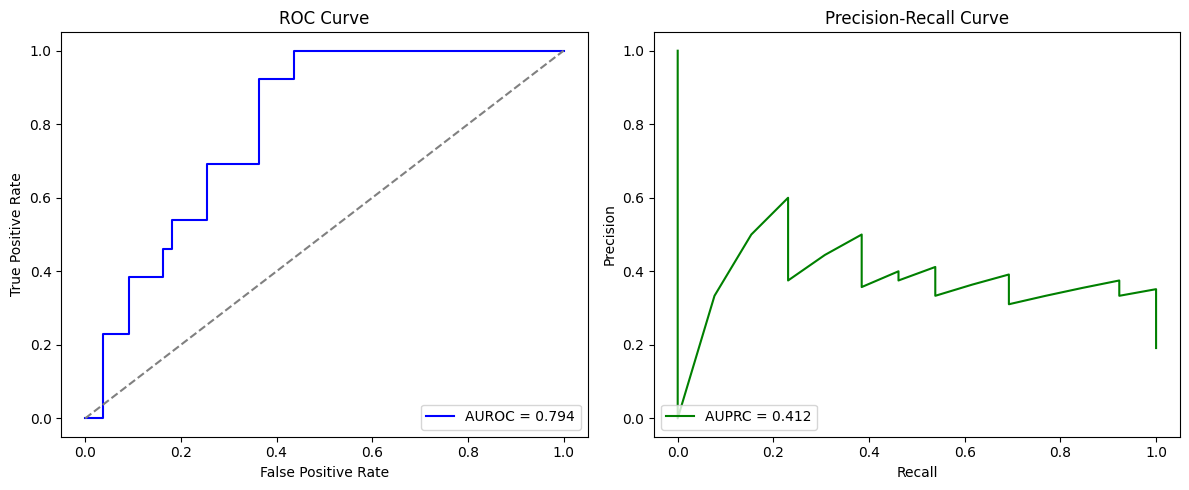

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def plot_metrics(y_true, y_scores):
    y_true = y_true.numpy()
    y_scores = y_scores.numpy()
    
    # ---------- AUROC ----------
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'AUROC = {roc_auc:.3f}')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    
    # ----------  AUPRC ----------
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'AUPRC = {ap_score:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()

model.eval()
all_labels = []
all_outputs = []
with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        all_outputs.append(torch.sigmoid(outputs))
        all_labels.append(labels)

all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs)

plot_metrics(all_labels, all_outputs)

In [ ]:
test_dataset = MultimodalDataset(
    f"{base_dir}/test/clinical.pkl",
    f"{base_dir}/test/mrna.pkl",
    f"{base_dir}/test/mutation.pkl",
    f"{base_dir}/test/labels.pkl"
)

test_loader = DataLoader(test_dataset, batch_size=32)



model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
test_loss = criterion(torch.tensor(all_probs), torch.tensor(all_labels)).item()
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Test Loss: {test_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

(68, 31)
(68, 2195)
(68, 17650)
Optimal threshold for F1: 0.98, F1 score: 0.4500
Test Loss: 1.1637
Precision: 0.3214
Recall: 0.7500
AUROC: 0.6637
Confusion Matrix:
True Negatives: 37
False Positives: 19
False Negatives: 3
True Positives: 9


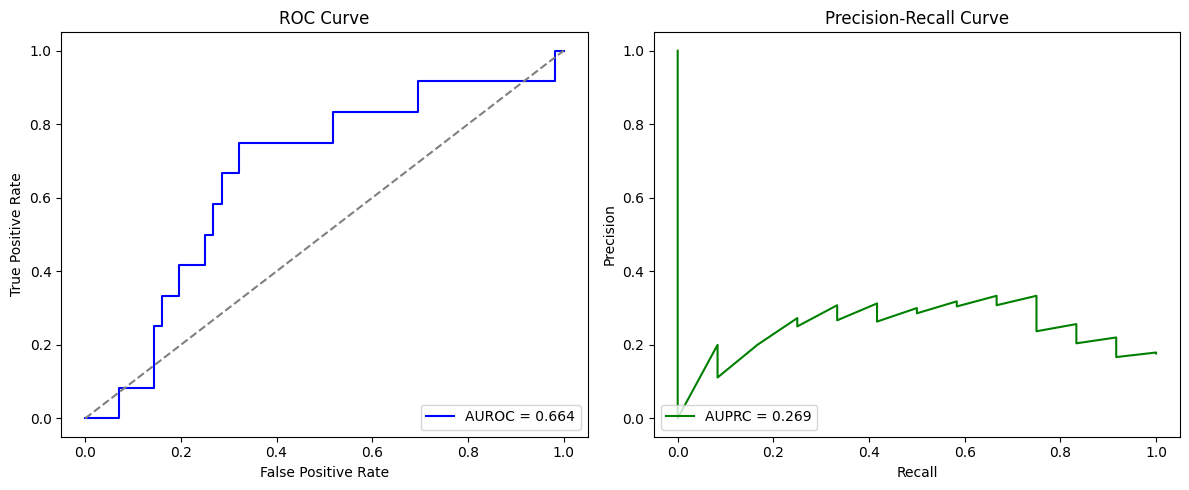

In [ ]:
model.eval()
all_labels = []
all_outputs = []
with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        outputs = model(clin, mrna, mut)
        all_outputs.append(torch.sigmoid(outputs))
        all_labels.append(labels)

all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs)

plot_metrics(all_labels, all_outputs)